# Fixed D / Vary M, N (Finite-M, softmax attention)

`N_LIST` と `M_LIST` の二重ループで実験する版（`N_TRIALS=1` 固定）。

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# ==================================
# Simple finite-M dynamics experiment
# (fixed D, M; vary N)
# softmax attention + data-only/history mask
# ==================================
D = 50
# それぞれ6個の候補
M_LIST = [10, 100, 1000, 10000] 
N_LIST = [10, 100, 1000] 

BATCH_SIZE = 300
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.001
ITERATIONS = 5000
EVAL_T_LIST = list(range(0, 32))

EVAL_BATCH_SIZE = 4096
SEED = 941
N_TRIALS = 1  
# 推論時の拡張設定
# - True : [w0, w1, ..., wt] を build_Z に渡して履歴を積む
# - False: 毎 step で 1-token のみ
USE_HISTORY_AT_INFERENCE = True
# マスク方式
# - "data_only"  : 最後 token は example token のみ参照（指定方式）
# - "history_cot": 最後 token は example + 過去 estimate token を参照（self のみ遮断）
ATTN_MASK_MODE = "history_cot"

DE = 2 * D + 2


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"device={device}, D={D}, M_LIST={M_LIST}, N_LIST={N_LIST}, "
    f"B={BATCH_SIZE}, iters={ITERATIONS}, lr={ADAM_LR}, l2={PARAM_L2_LAMBDA}, "
    f"trials={N_TRIALS}"
)


def sample_task_batch(batch_size, n, d=D, device=device):
    x = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, x)
    return x, y, w_star


def build_fixed_train_dataset(m, n):
    x, y, w_star = sample_task_batch(m, n=n)
    return {"X": x, "y": y, "w_star": w_star, "M": m, "N": n}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    return train_data["X"][idx], train_data["y"][idx], train_data["w_star"][idx]


def sample_w0_random(x, d=D, device=device):
    return torch.randn(x.shape[0], d, device=device)


def build_Z(x, y, w_prefix):
    b, d, n = x.shape
    i = len(w_prefix) - 1
    t = n + i + 1
    z = torch.zeros(b, DE, t, device=x.device)
    z[:, :d, :n] = x
    z[:, d, :n] = y
    for step, w_t in enumerate(w_prefix):
        z[:, d + 1 : d + 1 + d, n + step] = w_t
    z[:, -1, :] = 1.0
    return z


def build_attn_mask(T, L, device, mode="data_only"):
    # 共通初期化（指定方式）
    attn_mask = torch.zeros(T, T, device=device)

    if mode == "data_only":
        # attn_mask[-1, L:] = -inf
        attn_mask[-1, L:] = float("-inf")
    elif mode == "history_cot":
        # self のみ遮断（example + 過去 estimate は参照可）
        attn_mask[-1, T - 1] = float("-inf")
    else:
        raise ValueError(f"Unknown mask mode: {mode}")

    return attn_mask


def f_softmax_last(z, v, w, n, mask_mode="data_only"):
    B, de, T = z.shape
    z_last = z[:, :, -1]

    # bilinear score: z_t^T W z_last
    wz_last = torch.einsum("ij,bj->bi", w, z_last)
    logits = torch.einsum("bdt,bd->bt", z, wz_last) / np.sqrt(de)

    attn_mask = build_attn_mask(T=T, L=n, device=z.device, mode=mask_mode)
    logits = logits + attn_mask[-1].unsqueeze(0)

    attn = torch.softmax(logits, dim=-1)
    weighted = torch.einsum("bdt,bt->bd", z, attn)

    out_last = z_last + torch.einsum("ij,bj->bi", v, weighted)
    return out_last


def no_cot_train_loss(v, w, x, y, w_star):
    n = x.shape[2]
    w0 = sample_w0_random(x, D, x.device)
    z0 = build_Z(x, y, [w0])
    pred = f_softmax_last(z0, v, w, n=n, mask_mode="data_only")
    w_hat = pred[:, D + 1 : D + 1 + D]
    return ((w_hat - w_star) ** 2).sum(dim=1).mean()


def eval_dynamics_curve(
    v,
    w,
    n,
    t_list,
    batch_size=EVAL_BATCH_SIZE,
    use_history=USE_HISTORY_AT_INFERENCE,
    mask_mode=ATTN_MASK_MODE,
):
    x, y, w_star = sample_task_batch(batch_size, n=n)
    with torch.no_grad():
        w_hat = sample_w0_random(x, D, device)
        losses = {}
        losses[0] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()

        max_t = max(t_list)
        if use_history:
            w_hist = [w_hat]
            for t in range(1, max_t + 1):
                z = build_Z(x, y, w_hist)
                pred = f_softmax_last(z, v, w, n=n, mask_mode=mask_mode)
                w_hat = pred[:, D + 1 : D + 1 + D]
                losses[t] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()
                w_hist.append(w_hat)
        else:
            for t in range(1, max_t + 1):
                z = build_Z(x, y, [w_hat])
                pred = f_softmax_last(z, v, w, n=n, mask_mode=mask_mode)
                w_hat = pred[:, D + 1 : D + 1 + D]
                losses[t] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()

    return {t: losses[t] for t in t_list}


def parameter_l2_penalty(v, w):
    return v.pow(2).sum() + w.pow(2).sum()


def train_model_no_cot_finite(train_data, iterations=ITERATIONS):
    v = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    w = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([v, w], lr=ADAM_LR)

    for _ in range(iterations):
        x, y, w_star = sample_train_minibatch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(v, w, x, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(v, w)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return v.detach(), w.detach()

device=cpu, D=50, M_LIST=[100, 1000, 10000], N_LIST=[10, 100, 1000], B=300, iters=5000, lr=0.001, l2=0.001, trials=1


In [54]:
np.random.seed(SEED)
torch.manual_seed(SEED)

# results_by_m_n[m][n] = curve dict
results_by_m_n = {}
for m in M_LIST:
    results_by_m_n[m] = {}
    for n in N_LIST:
        # N_TRIALS=1 固定前提なので trial ループは回さない
        run_seed = SEED + 100000 * m + n
        np.random.seed(run_seed)
        torch.manual_seed(run_seed)

        train_data = build_fixed_train_dataset(m, n=n)
        v_tr, w_tr = train_model_no_cot_finite(train_data)
        eval_curve = eval_dynamics_curve(v_tr, w_tr, n=n, t_list=EVAL_T_LIST)

        results_by_m_n[m][n] = {
            "mean": {t: float(eval_curve[t]) for t in EVAL_T_LIST},
            "se": {t: 0.0 for t in EVAL_T_LIST},
        }

        print(f"M={m}, N={n}: done")

M=100, N=10: done
M=100, N=100: done
M=100, N=1000: done
M=1000, N=10: done
M=1000, N=100: done
M=1000, N=1000: done
M=10000, N=10: done
M=10000, N=100: done
M=10000, N=1000: done


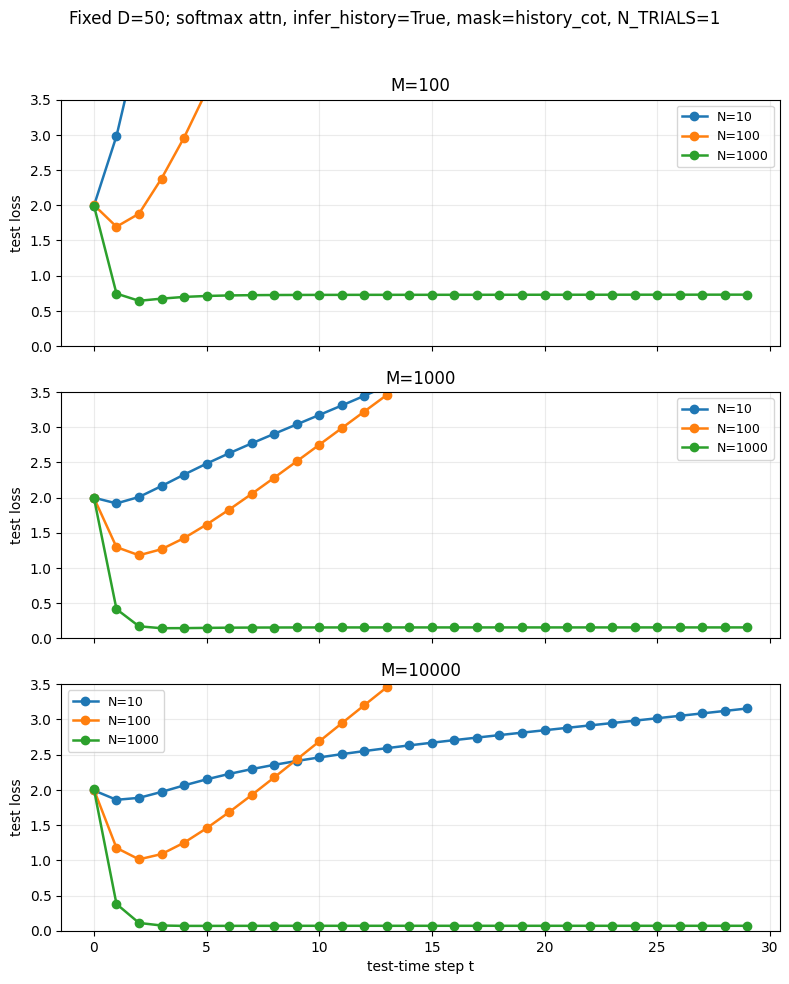

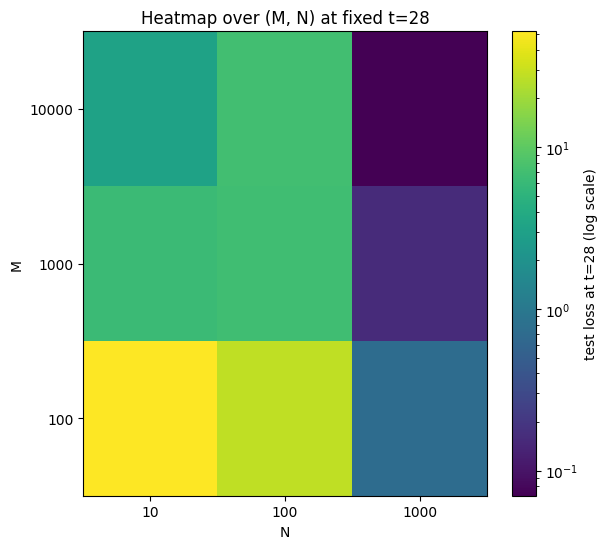

In [63]:
# 最後のヒートマップで使う固定時刻 t
T_HEATMAP = 28

# Mごとに N曲線を表示
n_rows = len(M_LIST)
fig, axes = plt.subplots(n_rows, 1, figsize=(8.0, 3.2 * n_rows), sharex=True)
if n_rows == 1:
    axes = [axes]

for ax, m in zip(axes, M_LIST):
    ts = np.array(EVAL_T_LIST)
    for n in N_LIST:
        mean_vals = np.array([results_by_m_n[m][n]["mean"][t] for t in ts])
        ax.plot(ts, mean_vals, marker="o", linewidth=1.8, label=f"N={n}")

    ax.set_ylim(0, 3.5)
    ax.set_ylabel("test loss")
    ax.set_title(f"M={m}")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

axes[-1].set_xlabel("test-time step t")
fig.suptitle(
    f"Fixed D={D}; softmax attn, infer_history={USE_HISTORY_AT_INFERENCE}, mask={ATTN_MASK_MODE}, N_TRIALS=1",
    y=1.02,
)
plt.tight_layout()
plt.show()

# 固定時刻 t の値で (M, N) ヒートマップ
if T_HEATMAP not in EVAL_T_LIST:
    raise ValueError(f"T_HEATMAP={T_HEATMAP} は EVAL_T_LIST に含めてください")

heat = np.zeros((len(M_LIST), len(N_LIST)), dtype=float)
for i, m in enumerate(M_LIST):
    for j, n in enumerate(N_LIST):
        heat[i, j] = results_by_m_n[m][n]["mean"][T_HEATMAP]

plt.figure(figsize=(1.4 * len(N_LIST) + 2, 1.2 * len(M_LIST) + 2))
heat_for_plot = np.maximum(heat, 1e-12)
vmin = float(np.min(heat_for_plot))
vmax = float(np.max(heat_for_plot))
if vmax <= vmin:
    vmax = vmin * (1.0 + 1e-6)
im = plt.imshow(
    heat_for_plot,
    aspect="auto",
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)
plt.colorbar(im, label=f"test loss at t={T_HEATMAP} (log scale)")
plt.xticks(np.arange(len(N_LIST)), [str(n) for n in N_LIST])
plt.yticks(np.arange(len(M_LIST)), [str(m) for m in M_LIST])
plt.gca().invert_yaxis()  # Mが大きい方を上に表示
plt.xlabel("N")
plt.ylabel("M")
plt.title(f"Heatmap over (M, N) at fixed t={T_HEATMAP}")
plt.tight_layout()
plt.show()

このコードとハイパーパラメータでは、3つの学習レジーム、つまり、overthinkingと、information limitedと、success regimeが存在することを、softmax attentionで成立することが示されている。とりあえずこの結果は使えそう。